# Signal Processing and Time Series Analysis

This notebook covers four independent analyses: custom convolution implementation and benchmarking, seismic signal smoothing, RL circuit frequency response modelling, and atmospheric methane time series decomposition and forecasting.

**Tools:** Python, NumPy, Pandas, Matplotlib, SciPy, statsmodels

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import integrate
import time
from statsmodels.tsa.seasonal import seasonal_decompose
import os

## 1. Discrete Convolution: Implementation and Benchmarking

### 1.1 Implementation
A discrete convolution function `myConv` is implemented from scratch. For input arrays of lengths L and K, the output has up to L + K − 1 non-zero elements, corresponding to the full range of overlap as one array slides across the other.

In [67]:
def myConv(f, w):
    f = np.asarray(f)
    w = np.asarray(w)
    N, M = len(f), len(w)
    g = np.zeros(N + M - 1)

    for n in range(N + M - 1):
        s = 0.0
        for k in range(N):
            j = n - k
            if 0 <= j < M:
                s += f[k] * w[j]
        g[n] = s
    return g


### 1.2 Validation Against NumPy

In [68]:
# Test myConv vs numpy.convolve
np.random.seed(0)  # so the test is repeatable

f = np.random.rand(10)
w = np.random.rand(6)

g_mine = myConv(f, w)
g_np = np.convolve(f, w)

diff = g_mine - g_np

print("max abs difference =", np.max(np.abs(diff)))
print("all close =", np.allclose(g_mine, g_np))


max abs difference = 4.440892098500626e-16
all close = True


### 1.3 Runtime Benchmarking
Runtime is measured for both implementations across array sizes spanning three orders of magnitude to characterize scaling behaviour.

In [69]:
sizes = [10, 100, 1000, 10000]

times_myconv = []
times_numpy = []

np.random.seed(0)

for N in sizes:
    f = np.random.rand(N)
    w = np.random.rand(N)

    # time myConv
    t1 = time.time()
    myConv(f, w)
    t2 = time.time()
    times_myconv.append(t2 - t1)

    # time numpy.convolve
    t1 = time.time()
    np.convolve(f, w)
    t2 = time.time()
    times_numpy.append(t2 - t1)


Plotting execution time on log-log axes to visualize algorithmic scaling:

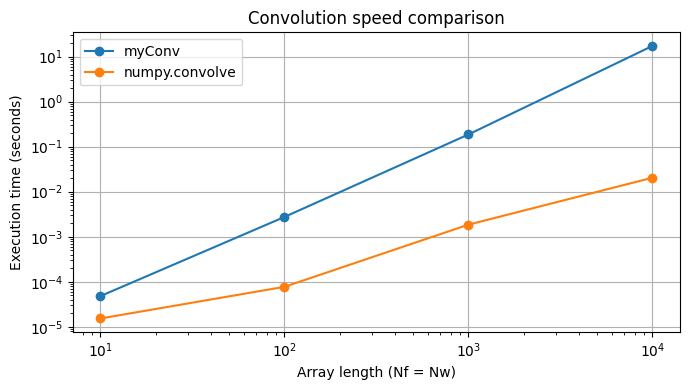

In [70]:
plt.figure(figsize=(7, 4))

plt.plot(sizes, times_myconv, marker="o", label="myConv")
plt.plot(sizes, times_numpy, marker="o", label="numpy.convolve")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Array length (Nf = Nw)")
plt.ylabel("Execution time (seconds)")
plt.title("Convolution speed comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2. Seismic Signal Processing with Gaussian Smoothing

### 2.1 Loading and Visualizing a Synthetic Seismogram
A synthetic seismogram for station RAYN is loaded and plotted over the first 800 seconds.

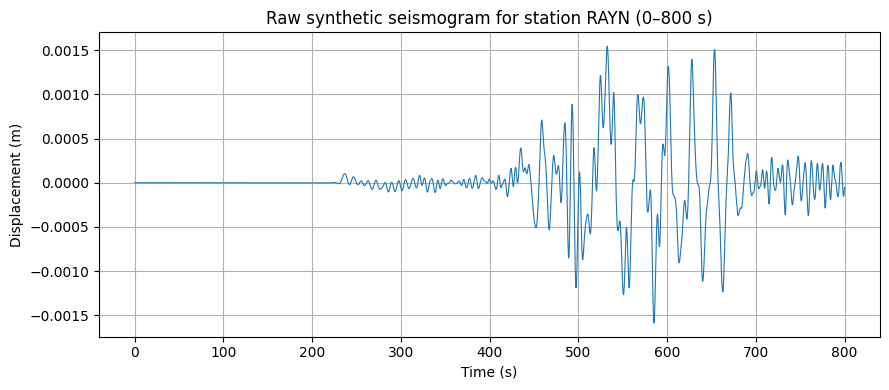

In [71]:
data = np.loadtxt("RAYN.II.LHZ.sem")
time = data[:, 0]
displacement = data[:, 1]

# Time window 0 to 800 seconds
mask = (time >= 0) & (time <= 800)
time_plot = time[mask]
disp_plot = displacement[mask]

plt.figure(figsize=(9, 4))
plt.plot(time_plot, disp_plot, linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Raw synthetic seismogram for station RAYN (0–800 s)")
plt.grid(True)
plt.tight_layout()
plt.show()


### 2.2 Gaussian Source-Time Functions
Gaussian functions with two different half-durations are defined and plotted to compare their spread and peak amplitude.

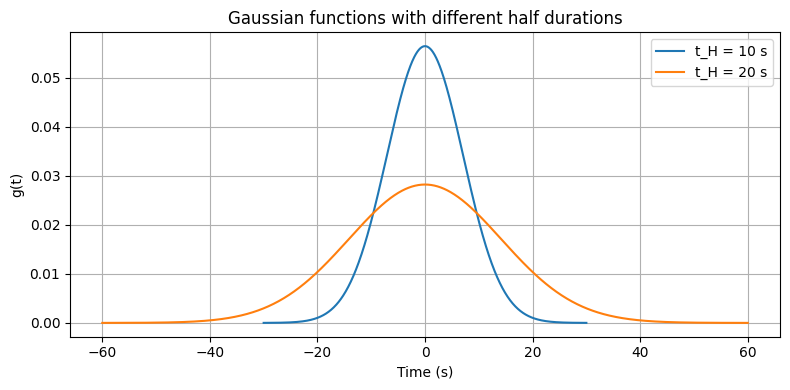

In [72]:
def gaussian(t, tH):
    return (1.0 / (tH * np.sqrt(np.pi))) * np.exp(-(t / tH)**2)

# Time array: sample within ±3 t_H
tH_values = [10.0, 20.0]

plt.figure(figsize=(8, 4))

for tH in tH_values:
    t = np.linspace(-3*tH, 3*tH, 1000)
    g = gaussian(t, tH)
    plt.plot(t, g, label="t_H = {} s".format(int(tH)))

plt.xlabel("Time (s)")
plt.ylabel("g(t)")
plt.title("Gaussian functions with different half durations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.3 Convolving the Seismogram with Gaussian Functions
The raw seismogram is convolved with each Gaussian to simulate the effect of different source durations on observed waveforms.

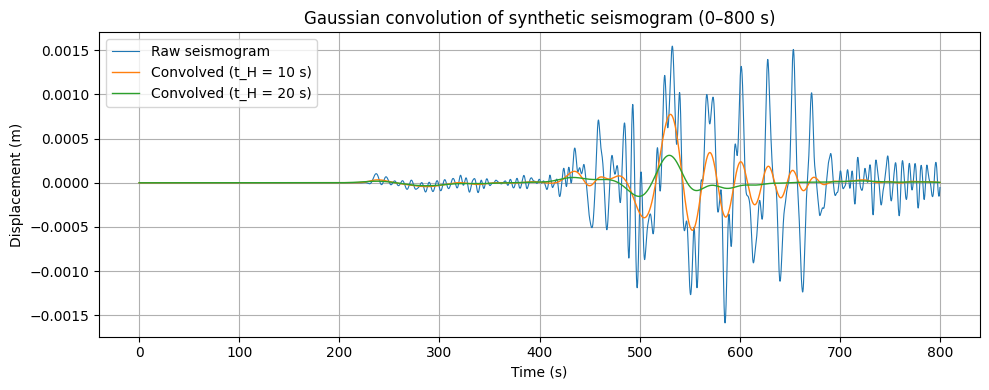

In [73]:
dt = time_plot[1] - time_plot[0]

def convolve_with_gaussian(x, dt, tH):
    tg = np.arange(-3*tH, 3*tH + dt, dt)
    g = gaussian(tg, tH)
    return np.convolve(x, g, mode="same") * dt

y10 = convolve_with_gaussian(disp_plot, dt, 10.0)
y20 = convolve_with_gaussian(disp_plot, dt, 20.0)

plt.figure(figsize=(10, 4))
plt.plot(time_plot, disp_plot, linewidth=0.8, label="Raw seismogram")
plt.plot(time_plot, y10, linewidth=1.0, label="Convolved (t_H = 10 s)")
plt.plot(time_plot, y20, linewidth=1.0, label="Convolved (t_H = 20 s)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Gaussian convolution of synthetic seismogram (0–800 s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. RL Circuit Frequency Response via Convolution

### 3.1 RL Response Function
An `RLresponse` function is implemented using the convolution of an input voltage signal with the circuit's impulse response. The impulse response is derived analytically from the RL transfer function and sampled at a given timestep `dt`.

In [74]:
def RLresponse(R, L, Vin, dt):
    Vin = np.asarray(Vin)

    # impulse response h[n] sampled at dt
    # truncate exponential part at 6 time constants so it decays to 0
    tau = L / R
    t_max = 6 * tau
    N = int(np.ceil(t_max / dt))
    
    n = np.arange(N + 1)  # 0..N
    t = n * dt
    
    h = -(R / L) * np.exp(-R * t / L) # -(R/L) e^{-Rt/L} for n>=0
    h[0] += 1.0 / dt

    # convolution with dt factor
    Vout_full = dt * np.convolve(Vin, h, mode="full")

    # return same length as Vin
    Vout = Vout_full[:len(Vin)]
    return Vout


### 3.2 Circuit Setup

In [75]:
R = 200.0
L = 40e-3

# dt small enough to see the response
dt = 1e-5 # 10 microseconds
t_end = 2e-3 # 2 milliseconds

t = np.arange(0, t_end + dt, dt)

# Discretized impulse D = [1/dt, 0, ...]
D = np.zeros_like(t)
D[0] = 1.0 / dt

# Discretized step H = [0.5, 1, 1, ...]
H = np.ones_like(t)
H[0] = 0.5


### 3.3 Step Response: Theoretical vs. Computed
The computed step response is overlaid on the analytical solution to validate the implementation.

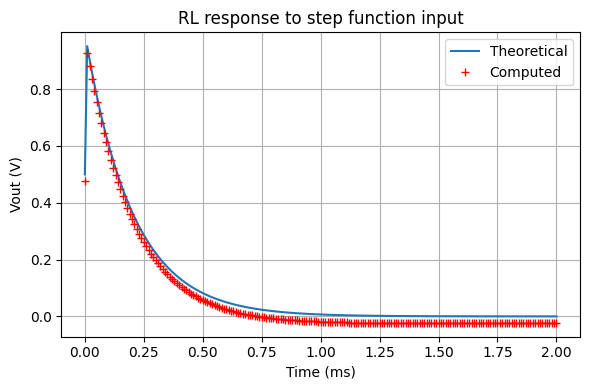

In [76]:
# Theoretical step response
S_theory = np.exp(-R*t/L) * H

S_comp = RLresponse(R, L, H, dt)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(t*1e3, S_theory, label="Theoretical")
plt.plot(t*1e3, S_comp, "+", label="Computed", color="red")
plt.xlabel("Time (ms)")
plt.ylabel("Vout (V)")
plt.title("RL response to step function input")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.4 Impulse Response: Theoretical vs. Computed
The computed impulse response is compared against the theoretical result.

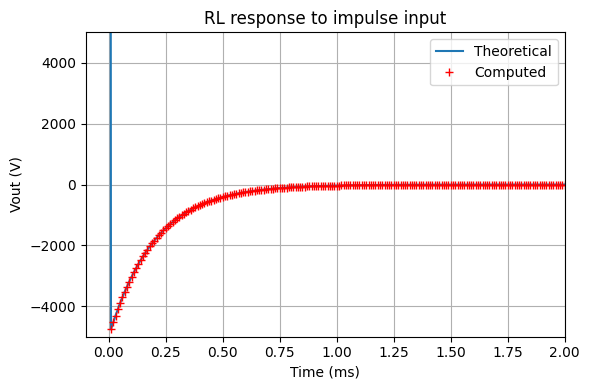

In [77]:
# Theoretical impulse response using discrete arrays
R_theory = D - (R/L) * np.exp(-R*t/L) * H

R_comp = RLresponse(R, L, D, dt)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(t*1e3, R_theory, label="Theoretical")
plt.plot(t*1e3, R_comp, "+", label="Computed", color="red")
plt.xlabel("Time (ms)")
plt.ylabel("Vout (V)")
plt.title("RL response to impulse input")
plt.legend()
plt.grid(True)
plt.xlim(-0.1, 2.0)
plt.ylim(-5000, 5000)
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Atmospheric Methane Time Series: Decomposition and Forecasting

### 4.1 Manual Decomposition: Polynomial Trend + Harmonic Seasonal Model
Monthly global mean methane data (NOAA) is loaded. A quadratic polynomial captures the long-term trend; a sum of sine and cosine harmonics (up to the 4th annual frequency) captures the seasonal cycle. The training period covers data up to and including 2019.

In [78]:
df = pd.read_csv("ch4_mm_gl.csv", comment="#")

# training data: start to end of 2019
train = df[df["year"] <= 2019]

t = train["decimal"].values
y = train["average"].values

Raw training data:

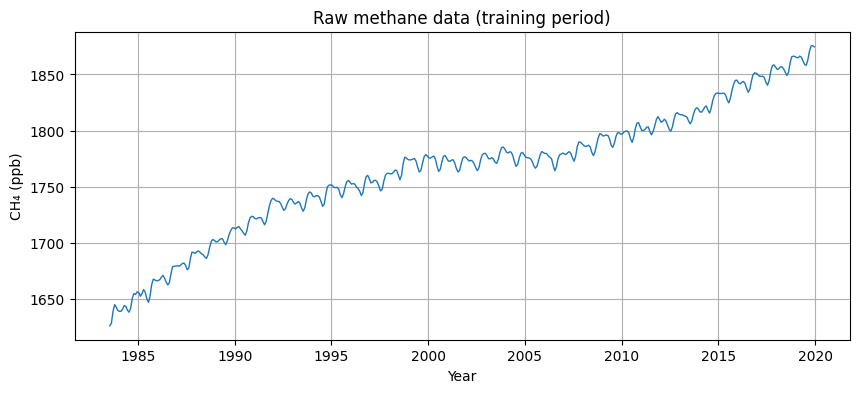

In [79]:
plt.figure(figsize=(10,4))
plt.plot(t, y, lw=1)
plt.xlabel("Year")
plt.ylabel("CH₄ (ppb)")
plt.title("Raw methane data (training period)")
plt.grid(True)
plt.show()

Fitting the quadratic trend and removing it:

In [80]:
# annual averages
annual = train.groupby("year")["average"].mean().reset_index()

# quadratic trend (k = 3)
coeffs = np.polyfit(annual["year"], annual["average"], deg=2)
trend_poly = np.poly1d(coeffs)

trend = trend_poly(t)
detrended = y - trend


Fitting the seasonal component using least-squares harmonic regression:

In [81]:
X = []
for n in range(1, 5):
    X.append(np.sin(2 * np.pi * n * t))
    X.append(np.cos(2 * np.pi * n * t))

X = np.column_stack(X)

seasonal_coeffs, *_ = np.linalg.lstsq(X, detrended, rcond=None)
seasonal = X @ seasonal_coeffs

residual = detrended - seasonal


Four-panel decomposition showing raw data, trend, seasonal, and residual components:

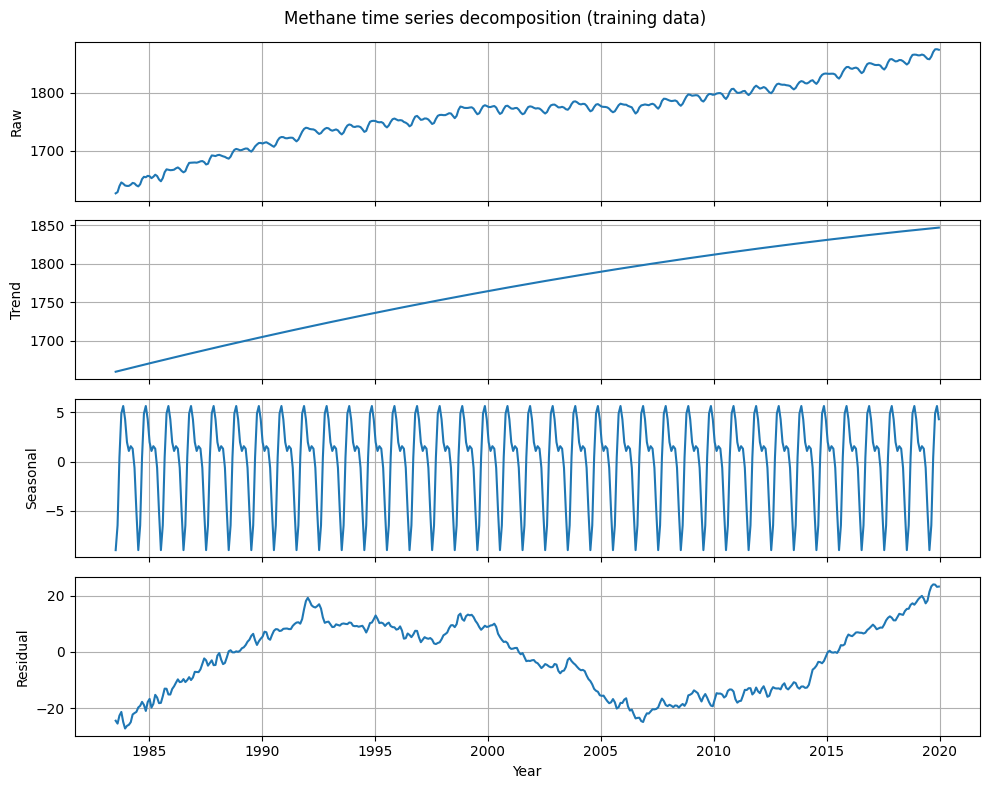

In [82]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t, y)
axs[0].set_ylabel("Raw")

axs[1].plot(t, trend)
axs[1].set_ylabel("Trend")

axs[2].plot(t, seasonal)
axs[2].set_ylabel("Seasonal")

axs[3].plot(t, residual)
axs[3].set_ylabel("Residual")
axs[3].set_xlabel("Year")

for ax in axs:
    ax.grid(True)

plt.suptitle("Methane time series decomposition (training data)")
plt.tight_layout()
plt.show()


The methane record shows a strong upward quadratic trend and a pronounced seasonal cycle dominated by the annual harmonic, with smaller higher-frequency components. After removing the trend and seasonal terms, the residuals show a periodic long-term structure, indicating that the polynomial + harmonic model does not capture the dominant variability in the training data.

### 4.2 Automated Decomposition Using statsmodels
An additive seasonal decomposition is applied using `statsmodels.seasonal_decompose` with a period of 12 months. An additive model is appropriate because the amplitude of the seasonal cycle is roughly constant over time.

In [83]:
df_full = pd.read_csv("ch4_mm_gl.csv", comment="#")

# create a datetime index
dates = pd.to_datetime(
    df_full["year"].astype(str) + "-" + df_full["month"].astype(str)
)

series = pd.Series(df_full["average"].values, index=dates)


Running the decomposition:

In [84]:
decomp = seasonal_decompose(
    series,
    model="additive",
    period=12
)

Four-panel visualization:

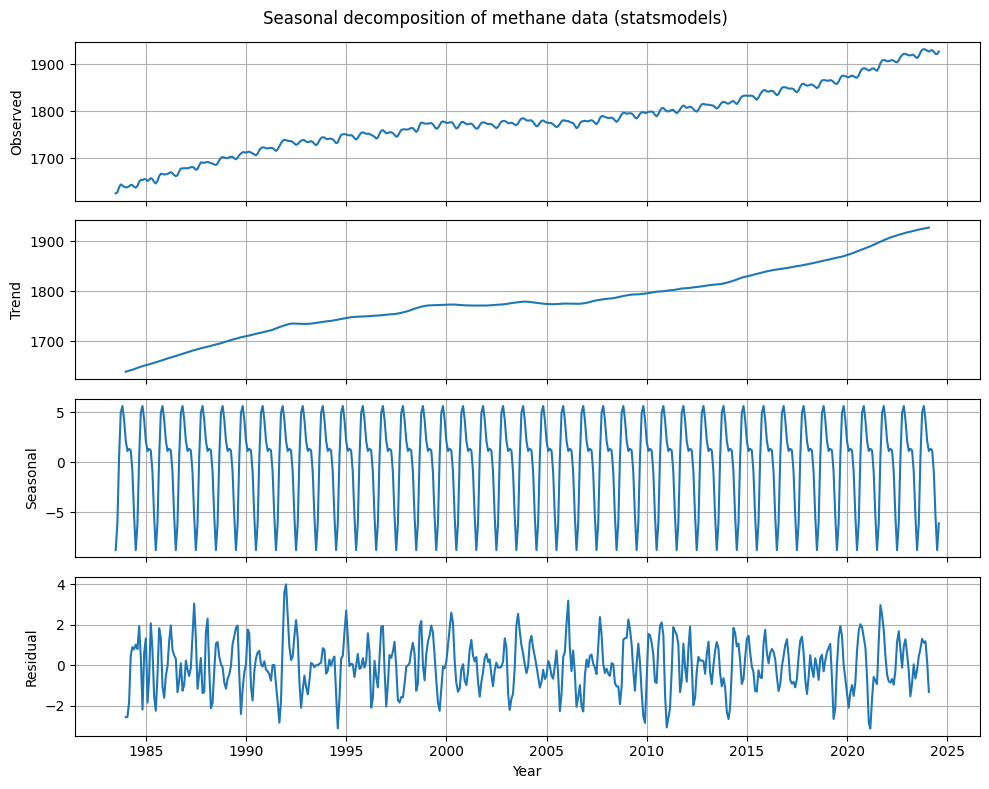

In [85]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(series)
axs[0].set_ylabel("Observed")

axs[1].plot(decomp.trend)
axs[1].set_ylabel("Trend")

axs[2].plot(decomp.seasonal)
axs[2].set_ylabel("Seasonal")

axs[3].plot(decomp.resid)
axs[3].set_ylabel("Residual")
axs[3].set_xlabel("Year")

for ax in axs:
    ax.grid(True)

plt.suptitle("Seasonal decomposition of methane data (statsmodels)")
plt.tight_layout()
plt.show()


An additive seasonal decomposition was used because the amplitude of the seasonal methane cycle is approximately constant over time rather than scaling with the mean concentration. A period of 12 was chosen to represent the annual cycle in the monthly data. The trend captures long-term methane growth, the seasonal component represents recurring annual variability, and the residuals contain short-term and unexplained fluctuations.

### 4.3 Comparing the Two Decomposition Methods


Both decomposition methods capture the same overall behavior in the methane time series. In both cases, the trend shows a long-term increase in methane concentration over the training period, with a noticeable slowdown in the early 2000s followed by accelerated growth after 2007. The seasonal components are also very similar between the two methods, showing a strong, repeating annual cycle with comparable amplitude and phase.

The main differences appear in the residuals. In the manual polynomial + sinusoidal fit (part a), the residuals exhibit longer-term structure and low-frequency variability, suggesting that not all slow variations are captured by the chosen polynomial order. In contrast, the statsmodels seasonal decomposition produces residuals that are more tightly centered around zero and appear more noise-like, indicating a smoother separation between trend and seasonal components.

These differences arise because the manual method assumes a fixed functional form (polynomial trend and fixed harmonics), while the automated seasonal decomposition uses moving averages and smoothing that adapt locally in time. As a result, the automated method absorbs more low-frequency variability into the trend component.

To quantify the difference, the root-mean-square error (RMSE) between the reconstructed signals from the two decompositions is small relative to the overall methane concentration range, confirming that both approaches provide consistent representations of the underlying signal despite methodological differences.

### 4.4 Out-of-Sample Forecasting (2020–2024)
Both models are used to forecast methane concentrations beyond the training period. Forecasts are compared against observed values using RMSE as the evaluation metric.

In [86]:
test_mask = series.index >= "2020-01-01"
series_test = series[test_mask]

# load + split
df = pd.read_csv("ch4_mm_gl.csv", comment="#")
train = df[df["year"] <= 2019].copy()
test  = df[df["year"] >= 2020].copy()

# trend fit on training data (quadratic)
t_train = train["decimal"].values
y_train = train["average"].values
trend_coeffs = np.polyfit(t_train, y_train, 2)

# simple seasonal model from training months
month_means = train.groupby("month")["average"].mean()
seasonal_by_month = month_means - month_means.mean()

def seasonal_model(t_dummy):
    # ignores t_dummy; uses the months in the test set
    months = test["month"].values
    return np.array([seasonal_by_month[m] for m in months])

# series_test + manual prediction
series_test = pd.Series(test["average"].values, index=test["decimal"].values)

t_test = test["decimal"].values
trend_pred_manual = np.polyval(trend_coeffs, t_test)
seasonal_pred_manual = seasonal_model(t_test)

pred_manual = trend_pred_manual + seasonal_pred_manual



Generating forecasts from the manual polynomial + harmonic model:

In [87]:
# use decimal years consistently
t_test = test["decimal"].values

trend_pred_manual = np.polyval(trend_coeffs, t_test)
seasonal_pred_manual = seasonal_model(t_test)

pred_manual = trend_pred_manual + seasonal_pred_manual


Generating forecasts from the statsmodels decomposition:

In [88]:
seasonal_cycle = decomp.seasonal[-12:].values
seasonal_pred_auto = np.tile(seasonal_cycle, len(series_test)//12 + 1)[:len(series_test)]

trend_slope = np.polyfit(np.arange(len(decomp.trend.dropna())),
                         decomp.trend.dropna(), 1)

trend_pred_auto = np.polyval(trend_slope, np.arange(len(series_test)))

pred_auto = trend_pred_auto + seasonal_pred_auto


Comparing observed vs. predicted methane concentrations (2020–2024):

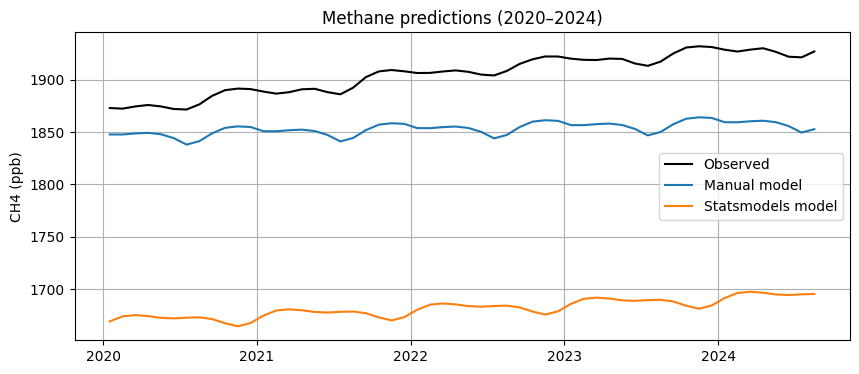

In [89]:
plt.figure(figsize=(10,4))
plt.plot(series_test.index, series_test, label="Observed", color="black")
plt.plot(series_test.index, pred_manual, label="Manual model")
plt.plot(series_test.index, pred_auto, label="Statsmodels model")
plt.legend()
plt.ylabel("CH4 (ppb)")
plt.title("Methane predictions (2020–2024)")
plt.grid(True)
plt.show()


RMSE for both models:

In [90]:
rmse_manual = np.sqrt(np.mean((series_test.values - pred_manual)**2))
rmse_auto = np.sqrt(np.mean((series_test.values - pred_auto)**2))

rmse_manual, rmse_auto


(np.float64(54.0256075144936), np.float64(223.99346249272222))

Both models underpredict methane concentrations during 2020–2024, indicating that post-2019 methane growth deviates from historical patterns. The manual polynomial-plus-harmonics model captures seasonality but cannot adapt to changes in growth rate. The statsmodels decomposition produces a smoother trend and therefore underestimates future values more strongly. These discrepancies suggest a structural change in methane emissions not represented in the training data.